In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import pearsonr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold

import loadmat as lm

# 1 Data processing

## 1.1 Load data

In [ ]:
data = lm.loadmat('MIs.mat')['data']

# shape: (nbSamples, nbChannels, nbTrials)
LH = data['LH']     # left hand
RH = data['RH']     # right hand
BH = data['BH']     # both hands
REST = data['REST'] # feet

fs = 500  # sampling rate in Hz
t = np.linspace(-1.5, 3.5, LH.shape[0])
electrodes = {0: 'CP5', 1: 'FC5', 2: 'C3', 3: 'C1', 4: 'C2', 5: 'C4', 6: 'FC6', 7: 'CP6'}

# Exclude channel 6, as it is broken / zero
channels = [i for i in electrodes if i != 5]

## 1.2 Spectrograms

In [ ]:
def plot_spectrogram(sig, fs, ax, title, fmax=40):
    # Calculate spectrograms & average
    f, t_spec, Sxx = signal.spectrogram(sig, fs=fs, axis=0)
    Sxx_mean = Sxx.mean(axis=1)
    # Plot, limit to 40 Hz
    ax.pcolormesh(t_spec, f, Sxx_mean, shading='gouraud')
    ax.set_ylim(0, fmax)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')
    ax.set_title(title)

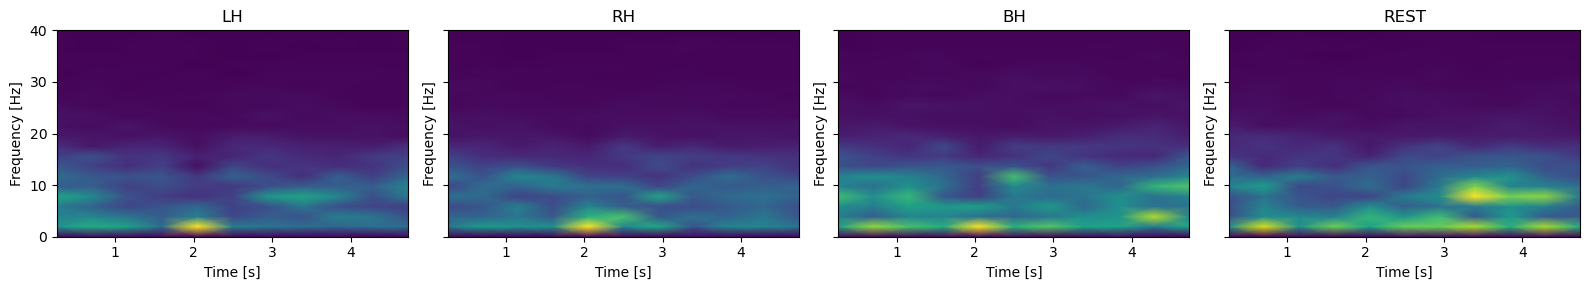

In [ ]:
conditions = {'LH': LH, 'RH': RH, 'BH': BH, 'REST': REST}
channel = 3

# Plot for each condition
fig, axes = plt.subplots(1, len(conditions), figsize=(16, 3), sharey=True)
for ax, (name, cond) in zip(axes, conditions.items()):
    plot_spectrogram(cond[:, channel, :], fs, ax, name)

plt.tight_layout()
plt.show()

## 1.3 Time series (ERD/ERS)

In [ ]:
def bandpass_filter(sig, lowcut, highcut, fs, order=4):
    sos = signal.butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, sig, axis=0)

In [ ]:
def sliding_window_power(sig, fs, window_sec=0.5, step_sec=0.05):
    window = int(window_sec * fs)
    step = int(step_sec * fs)
    n_samples = sig.shape[0]
    centers = []
    powers = []
    for start in range(0, n_samples - window, step):
        seg = sig[start:start + window]
        powers.append(np.mean(seg ** 2, axis=0))
        centers.append(start + window / 2)
    return np.array(centers), np.array(powers)

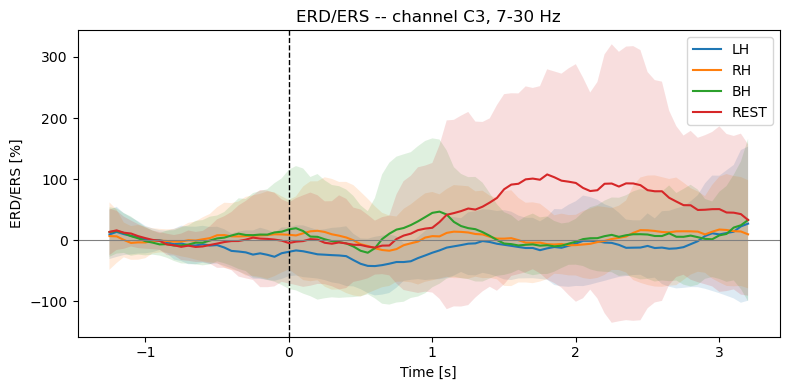

In [ ]:
# We want the 7-30 frequency bands
band = (7, 30)
channel = 2

fig, ax = plt.subplots(figsize=(8, 4))
for name, cond in conditions.items():
    # Filter & calculate avg. power per window
    filtered = bandpass_filter(cond[:, channel, :], *band, fs)
    centers, powers = sliding_window_power(filtered, fs)
    window_t = t[centers.astype(int)]

    # Calculate baseline (avg. during first second of recording)
    baseline = powers[window_t < -0.5].mean(axis=0)

    # Normalize
    erd_ers = (powers - baseline) / baseline * 100

    # Plot with error bands
    mean_erd_ers = erd_ers.mean(axis=1)
    std_erd_ers = erd_ers.std(axis=1)
    ax.plot(window_t, mean_erd_ers, label=name)
    ax.fill_between(window_t, mean_erd_ers - std_erd_ers, mean_erd_ers + std_erd_ers, alpha=0.15)

ax.axvline(0, color='k', ls='--', lw=1)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Time [s]')
ax.set_ylabel('ERD/ERS [%]')
ax.legend()
ax.set_title(f'ERD/ERS -- channel {electrodes[channel]}, {band[0]}-{band[1]} Hz')
plt.tight_layout()
plt.show()

# 2 Feature Extraction

## 2.1 Periodograms, correlation & feature vectors

In [ ]:
def compute_periodogram(sig, fs):
    f, Pxx = signal.periodogram(sig, fs=fs, axis=0)
    return f, Pxx

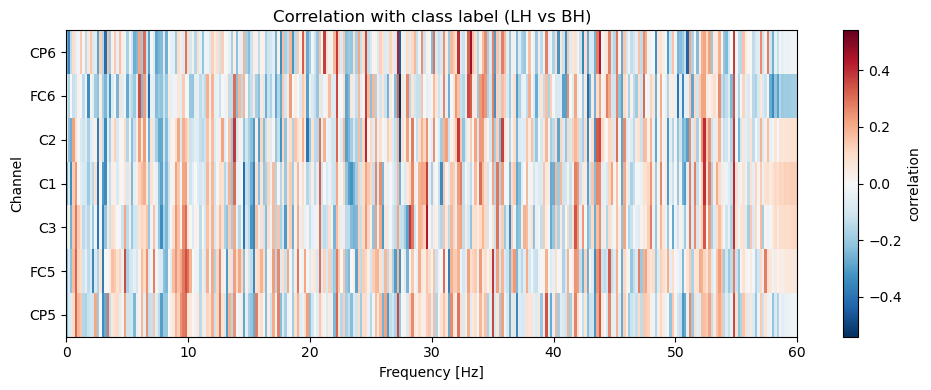

In [ ]:
class_a, class_b = 'LH', 'BH'
Xa, Xb = conditions[class_a][:, channels, :], conditions[class_b][:, channels, :]

# Compute periodograms
f, pg_a = compute_periodogram(Xa, fs)
_, pg_b = compute_periodogram(Xb, fs)

# Stack & create label vector
pgs = np.concatenate([pg_a, pg_b], axis=-1)
lbls = np.concatenate([np.zeros(pg_a.shape[-1]), np.ones(pg_b.shape[-1])])

# 0-center data & labels
pgs_c = pgs - pgs.mean(axis=-1, keepdims=True)
lbls_c = lbls - lbls.mean()

# Calculate covariance & correlation
cov = (pgs_c * lbls_c).mean(axis=-1)
corr = cov / (pgs.std(axis=-1) * lbls.std())

# Plot correlation as a function of frequency, per channel
fmax = 60
fig, ax = plt.subplots(figsize=(10, 4))
vmax = np.abs(corr).max()
im = ax.pcolormesh(f, np.arange(len(channels)), corr.T, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(np.arange(len(channels)))
ax.set_yticklabels([electrodes[c] for c in channels])
ax.set_xlim(0, fmax)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Channel')
ax.set_title(f'Correlation with class label ({class_a} vs {class_b})')
fig.colorbar(im, ax=ax, label='correlation')
plt.tight_layout()
plt.show()

## 2.2 Class discrimination

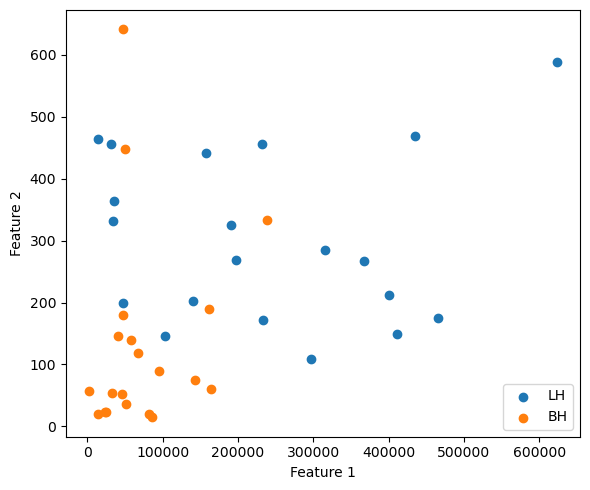

In [ ]:
n_features = 3

# Calculate indices of best N features
flat_idx = np.argsort(-np.abs(corr), axis=None)[:n_features]
freq_idx, chan_idx = np.unravel_index(flat_idx, corr.shape)

# Build feature vector
features_a = pg_a[freq_idx, chan_idx, :].T
features_b = pg_b[freq_idx, chan_idx, :].T

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(features_a[:, 0], features_a[:, 1], label=class_a)
ax.scatter(features_b[:, 0], features_b[:, 1], label=class_b)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()


# 3 Classification

## 3.1 LDA classifier

In [ ]:
X = np.concatenate([features_a, features_b], axis=-0)
lda = LinearDiscriminantAnalysis().fit(X, lbls)
print(f'Training accuracy: {(lda.predict(X) == lbls).mean():.2%}')

Training accuracy: 85.00%


# 4 Common Spatial Pattern (CSP) algorithm

## 4.1 CSP feature extraction

In [ ]:
# 2. Calculate cov matrices per trial, per class
def covariance_matrix(X):
    n_trials = X.shape[2]
    covs = np.zeros((n_trials, X.shape[1], X.shape[1]))
    for i in range(n_trials):
        trial = X[:, :, i].T
        cov = trial @ trial.T
        covs[i] = cov / np.trace(cov)
    return covs

In [ ]:
# 3. Eigenvalue decomposition & sorting
def csp_filters(c1, c2):
    import scipy.linalg
    c1_cov_mean = np.mean(covariance_matrix(c1), axis=0)
    c2_cov_mean = np.mean(covariance_matrix(c2), axis=0)
    value, vector = scipy.linalg.eig(c1_cov_mean, c2_cov_mean)
    return vector[:, np.argsort(-value.real)]

In [ ]:
# 5. Project signals onto filters
def csp_project(X, W, n_pairs):
    filters = np.concatenate([W[:, :n_pairs], W[:, -n_pairs:]], axis=1)
    projected = np.einsum('cf,sct->fst', filters, X)
    return projected

# 6. Covariance as features
def csp_features(projected):
    return np.log(np.var(projected, axis=1, ddof=1)).T

In [ ]:
class_a, class_b = 'LH', 'REST'
n_pairs = 2

# 1. Preprocessing, filter to relevant bands
Xa = bandpass_filter(conditions[class_a][:, channels, :], *band, fs)
Xb = bandpass_filter(conditions[class_b][:, channels, :], *band, fs)

# Find filters
W = csp_filters(Xa, Xb)

## 4.2 Decision boundary

Training accuracy: 90.00%


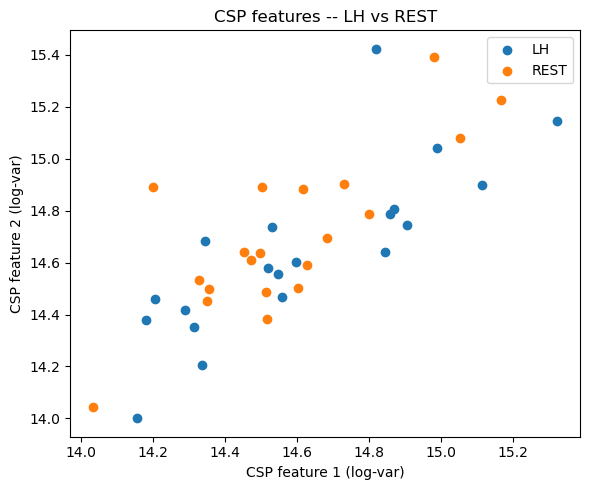

In [ ]:
# Project & build feature and label vectors
projected = csp_project(np.concatenate([Xa, Xb], axis=2), W, n_pairs)
features = csp_features(projected)
labels = np.concatenate([np.zeros(Xa.shape[2]), np.ones(Xb.shape[2])])

# Train classifier
lda_csp = LinearDiscriminantAnalysis().fit(features, labels)
print(f'Training accuracy: {(lda_csp.predict(features) == labels).mean():.2%}')

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(features[labels == 0, 0], features[labels == 0, 1], label=class_a)
ax.scatter(features[labels == 1, 0], features[labels == 1, 1], label=class_b)
ax.set_xlabel('CSP feature 1 (log-var)')
ax.set_ylabel('CSP feature 2 (log-var)')
ax.set_title(f'CSP features -- {class_a} vs {class_b}')
ax.legend()
plt.tight_layout()
plt.show()

## 4.3 4-fold cross-validation

In [ ]:
def four_fold_cv(Xa, Xb, n_pairs):
    n_trials = Xa.shape[2]
    n_folds = 4
    block_size = n_trials // n_folds
    accuracies = []

    for fold in range(n_folds):
        test_idx = np.arange(fold * block_size, (fold + 1) * block_size)
        train_idx = np.setdiff1d(np.arange(n_trials), test_idx)

        Xa_train, Xa_test = Xa[:, :, train_idx], Xa[:, :, test_idx]
        Xb_train, Xb_test = Xb[:, :, train_idx], Xb[:, :, test_idx]

        W_fold = csp_filters(Xa_train, Xb_train)

        train_features = csp_features(csp_project(np.concatenate([Xa_train, Xb_train], axis=2), W_fold, n_pairs))
        train_labels = np.concatenate([np.zeros(Xa_train.shape[2]), np.ones(Xb_train.shape[2])])
        test_features = csp_features(csp_project(np.concatenate([Xa_test, Xb_test], axis=2), W_fold, n_pairs))
        test_labels = np.concatenate([np.zeros(Xa_test.shape[2]), np.ones(Xb_test.shape[2])])

        clf = LinearDiscriminantAnalysis().fit(train_features, train_labels)
        accuracies.append((clf.predict(test_features) == test_labels).mean())

    return np.array(accuracies)

In [ ]:
accuracies = four_fold_cv(Xa, Xb, n_pairs)
print(f'Accuracy: {accuracies.mean():.2%} +/- {accuracies.std():.2%}')
print('per fold:', np.round(accuracies, 3))

Accuracy: 72.50% +/- 8.29%
per fold: [0.8 0.8 0.7 0.6]
